<a href="https://colab.research.google.com/github/Maria-Manzini/FUTURE_DS_01/blob/main/Task1_Sales_Analysis_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Business Sales Performance Analytics
## Future Interns | Data Science & Analytics Internship

### Project Overview
This notebook analyzes real business sales data to uncover:
- Monthly and yearly revenue trends
- Top-selling products and product lines
- Regional and country-level performance
- Key KPIs and actionable business recommendations

**Tools Used:** Python, Pandas, Matplotlib
**Dataset:** Sample Sales Data (Kaggle)
**Author:** Maria Manzini

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready ")

Libraries ready 


In [4]:
df = pd.read_csv('/content/sample_data/sales_data_sample.csv', encoding='latin1')

print("Dataset loaded ")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded 
Shape: 2823 rows × 25 columns

First 5 rows:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [6]:
print("=== DATA QUALITY CHECK ===")
print(f"\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
df.dropna(subset=['SALES', 'ORDERDATE', 'PRODUCTLINE'], inplace=True)

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month
df['MONTH_NAME'] = df['ORDERDATE'].dt.strftime('%b')

df['SALES'] = pd.to_numeric(df['SALES'], errors='coerce')
df.dropna(subset=['SALES'], inplace=True)

print(f"\nCleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['ORDERDATE'].min().date()} to {df['ORDERDATE'].max().date()}")
print(f"Total Revenue: ${df['SALES'].sum():,.2f}")
print("\nData cleaning complete ")

=== DATA QUALITY CHECK ===

Missing values per column:
ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

Duplicate rows: 0

Cleaned dataset: 2823 rows × 28 columns
Date range: 2003-01-06 to 2005-05-31
Total Revenue: $10,032,628.85

Data cleaning complete 


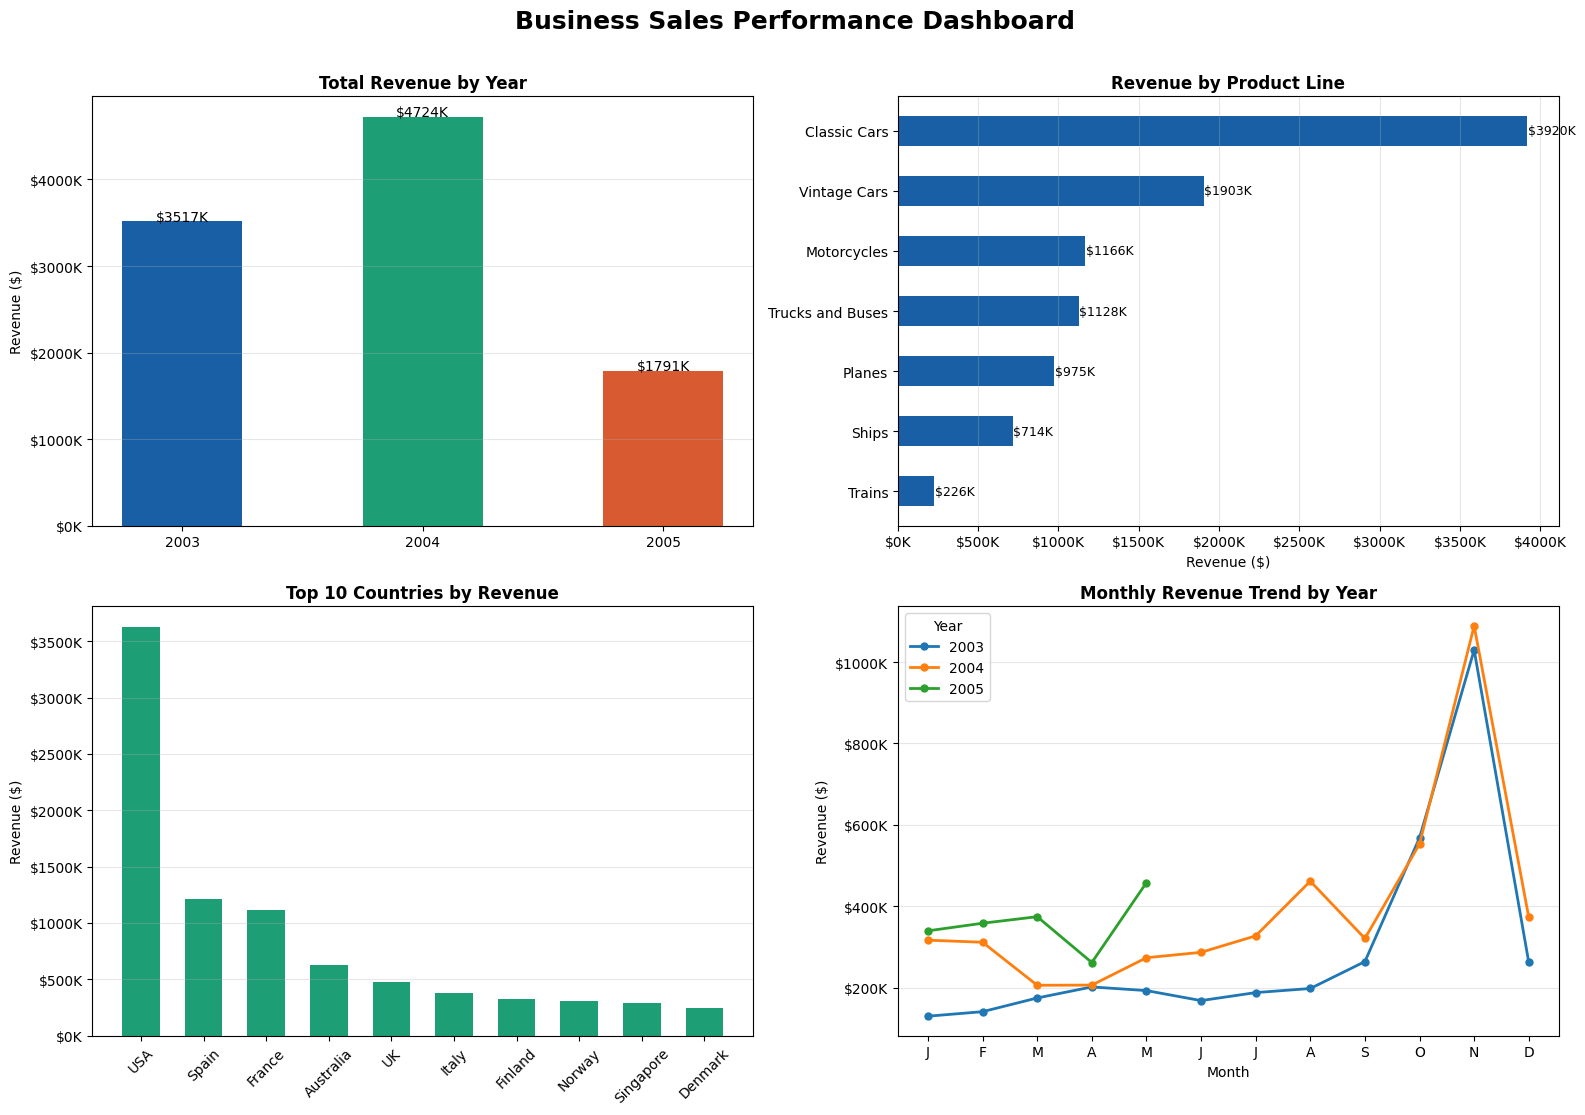

Dashboard saved 


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Business Sales Performance Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# Chart 1: Revenue by year (bar)
yearly = df.groupby('YEAR')['SALES'].sum()
bars = axes[0,0].bar(yearly.index.astype(str), yearly.values,
                      color=['#185FA5','#1D9E75','#D85A30'], width=0.5)
axes[0,0].set_title('Total Revenue by Year', fontweight='bold')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, yearly.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 5000,
                   f'${val/1000:.0f}K', ha='center', fontsize=10)
axes[0,0].grid(axis='y', alpha=0.3)

# Chart 2: Revenue by product line (horizontal bar)
product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values()
axes[0,1].barh(product.index, product.values, color='#185FA5', height=0.5)
axes[0,1].set_title('Revenue by Product Line', fontweight='bold')
axes[0,1].set_xlabel('Revenue ($)')
axes[0,1].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
for i, val in enumerate(product.values):
    axes[0,1].text(val + 2000, i, f'${val/1000:.0f}K',
                   va='center', fontsize=9)
axes[0,1].grid(axis='x', alpha=0.3)

# Chart 3: Top 10 countries by revenue
country = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(10)
axes[1,0].bar(country.index, country.values, color='#1D9E75', width=0.6)
axes[1,0].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[1,0].set_ylabel('Revenue ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
axes[1,0].grid(axis='y', alpha=0.3)

# Chart 4: Monthly revenue trend
monthly = df.groupby(['YEAR','MONTH'])['SALES'].sum().reset_index()
for year in monthly['YEAR'].unique():
    yd = monthly[monthly['YEAR']==year]
    axes[1,1].plot(yd['MONTH'], yd['SALES'],
                   marker='o', linewidth=2, label=str(year), markersize=5)
axes[1,1].set_title('Monthly Revenue Trend by Year', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Revenue ($)')
axes[1,1].yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
axes[1,1].legend(title='Year')
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(['J','F','M','A','M','J',
                            'J','A','S','O','N','D'])

plt.tight_layout()
plt.savefig('sales_dashboard_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ")

In [8]:
print("=" * 50)
print("   BUSINESS SALES PERFORMANCE INSIGHTS")
print("=" * 50)

print(f"\nTotal Revenue: ${df['SALES'].sum():,.2f}")
print(f"Total Orders: {df['ORDERNUMBER'].nunique():,}")
print(f"Average Order Value: ${df['SALES'].mean():,.2f}")

best_year = yearly.idxmax()
print(f"\nBest Year: {best_year} (${yearly[best_year]:,.2f})")

top_product = df.groupby('PRODUCTLINE')['SALES'].sum().idxmax()
print(f"Top Product Line: {top_product}")

top_country = df.groupby('COUNTRY')['SALES'].sum().idxmax()
print(f"Top Country: {top_country}")

print("\nRECOMMENDATIONS:")
print("1. Double down on top performing product lines")
print("   with increased inventory and marketing spend")
print("2. Expand operations in top revenue countries")
print("3. Investigate Q4 spikes to replicate")
print("   peak season strategies year-round")
print("4. Analyse underperforming countries for")
print("   growth or exit decisions")
print("=" * 50)

   BUSINESS SALES PERFORMANCE INSIGHTS

Total Revenue: $10,032,628.85
Total Orders: 307
Average Order Value: $3,553.89

Best Year: 2004 ($4,724,162.60)
Top Product Line: Classic Cars
Top Country: USA

RECOMMENDATIONS:
1. Double down on top performing product lines
   with increased inventory and marketing spend
2. Expand operations in top revenue countries
3. Investigate Q4 spikes to replicate
   peak season strategies year-round
4. Analyse underperforming countries for
   growth or exit decisions


## Conclusions

### What I Learned
- How to load and clean a real-world messy dataset
- How to extract meaningful KPIs from raw sales data
- How to build multi-panel dashboards using Matplotlib
- How to translate data findings into business recommendations

### Challenges Faced
- The dataset had encoding issues (solved with latin1 encoding)
- Date formatting required conversion before analysis
- Grouping data by multiple dimensions needed careful indexing

### Key Takeaways
This analysis shows that revenue is heavily concentrated in
a few product lines and countries — a classic 80/20 pattern
common in real business data.